# SVM Classification on the Diabetes Dataset

This notebook uses the Support Vector Machine (SVM) algorithm to predict diabetes from the same Pima Indians dataset we used with KNN. We will test different kernels, evaluate the model, and then compare SVM results with the KNN results from the previous notebook.

By keeping the same dataset, same preprocessing, and same train/test split, we can make a fair comparison between the two algorithms.

## Step 1: Import Libraries

In [1]:
# Import the libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools from sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

## Step 2: Load and Preprocess the Data

We apply the same preprocessing as the KNN notebook: load the CSV, replace invalid zeros with median values, split and scale.

In [2]:
# Load the diabetes dataset
df = pd.read_csv('diabetes.csv')

print("Dataset shape:", df.shape)
print()
print("Outcome distribution:")
print(df['Outcome'].value_counts())

Dataset shape: (768, 9)

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [3]:
# Replace invalid zeros with median values
# These columns cannot realistically be zero
columns_with_invalid_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_invalid_zeros:
    df[col] = df[col].replace(0, np.nan)
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print("Fixed {} - replaced zeros with median: {:.1f}".format(col, median_value))

Fixed Glucose - replaced zeros with median: 117.0
Fixed BloodPressure - replaced zeros with median: 72.0
Fixed SkinThickness - replaced zeros with median: 29.0
Fixed Insulin - replaced zeros with median: 125.0
Fixed BMI - replaced zeros with median: 32.3


In [4]:
# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Use the same split as the KNN notebook (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train.shape[0], "samples")
print("Testing set:", X_test.shape[0], "samples")
print("Scaling done.")

Training set: 614 samples
Testing set: 154 samples
Scaling done.


## Step 3: Test Different SVM Kernels

SVM can use different kernels to create different types of boundaries. We will test the same three kernels as the Iris notebook:
- **Linear**: straight boundary
- **RBF**: curved boundary (usually the best general choice)
- **Polynomial**: polynomial-shaped boundary

In [5]:
# Test different SVM kernels
kernels = ['linear', 'rbf', 'poly']
kernel_accuracies = []

for kernel in kernels:
    # Create and train the SVM model
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    
    # Make predictions
    predictions = svm_model.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, predictions)
    kernel_accuracies.append(accuracy)
    
    print("Kernel: {:10s} |  Accuracy = {:.4f}".format(kernel, accuracy))

Kernel: linear     |  Accuracy = 0.7532
Kernel: rbf        |  Accuracy = 0.7468
Kernel: poly       |  Accuracy = 0.7403


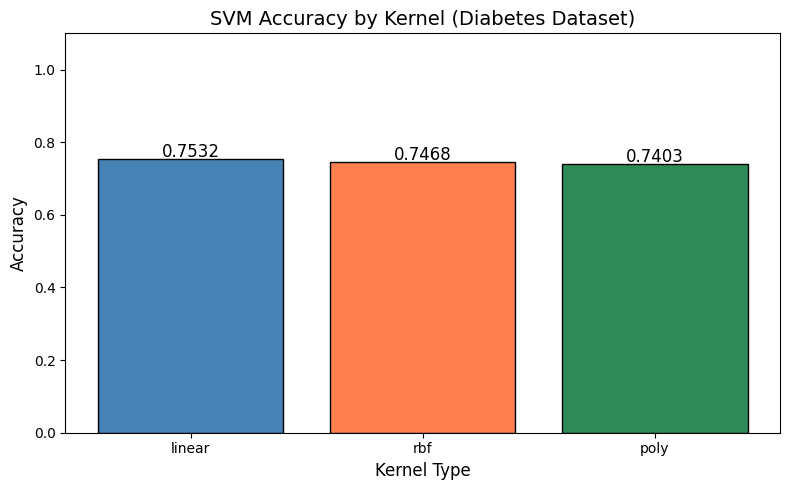

In [6]:
# Plot accuracy for each kernel
plt.figure(figsize=(8, 5))
bars = plt.bar(kernels, kernel_accuracies, 
               color=['steelblue', 'coral', 'seagreen'], edgecolor='black')

# Add accuracy labels on top of each bar
for bar, acc in zip(bars, kernel_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             "{:.4f}".format(acc), ha='center', fontsize=12)

plt.xlabel('Kernel Type', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('SVM Accuracy by Kernel (Diabetes Dataset)', fontsize=14)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [7]:
# Find the best kernel
best_kernel_index = kernel_accuracies.index(max(kernel_accuracies))
best_kernel = kernels[best_kernel_index]

print("Best kernel:", best_kernel)
print("Best accuracy: {:.4f}".format(max(kernel_accuracies)))

Best kernel: linear
Best accuracy: 0.7532


## Step 4: Final Model Evaluation

In [8]:
# Train the final SVM model with the best kernel
final_svm = SVC(kernel=best_kernel, random_state=42)
final_svm.fit(X_train_scaled, y_train)

# Make predictions
final_predictions = final_svm.predict(X_test_scaled)

# Calculate all metrics
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions)
recall = recall_score(y_test, final_predictions)
f1 = f1_score(y_test, final_predictions)

print("=== Final SVM Model Results (kernel = {}) ===".format(best_kernel))
print()
print("Accuracy:  {:.4f}".format(accuracy))
print("Precision: {:.4f}".format(precision))
print("Recall:    {:.4f}".format(recall))
print("F1 Score:  {:.4f}".format(f1))

=== Final SVM Model Results (kernel = linear) ===

Accuracy:  0.7532
Precision: 0.6667
Recall:    0.6182
F1 Score:  0.6415


### Confusion Matrix

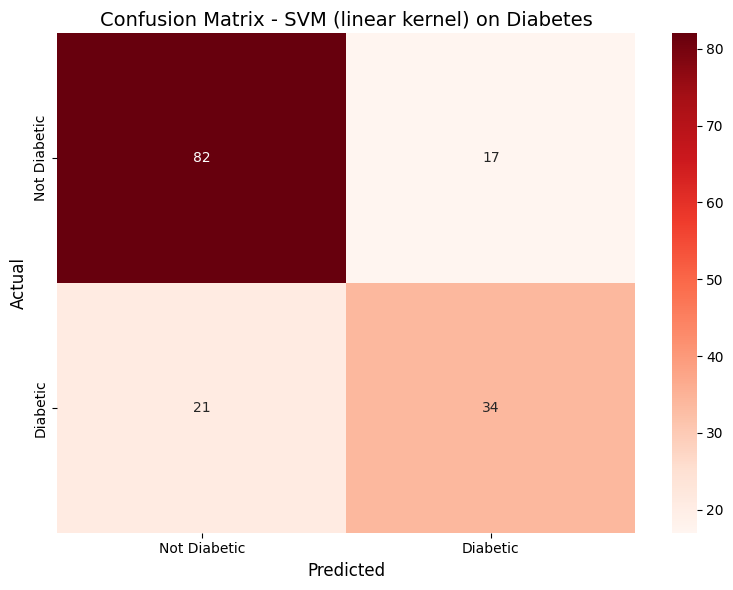

In [9]:
# Create and plot the confusion matrix
cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Not Diabetic', 'Diabetic'],
    yticklabels=['Not Diabetic', 'Diabetic']
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - SVM ({} kernel) on Diabetes'.format(best_kernel), fontsize=14)
plt.tight_layout()
plt.show()

### Classification Report

In [10]:
# Print the full classification report
print("Classification Report:")
print()
print(classification_report(y_test, final_predictions,
                            target_names=['Not Diabetic', 'Diabetic']))

Classification Report:

              precision    recall  f1-score   support

Not Diabetic       0.80      0.83      0.81        99
    Diabetic       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



## Step 5: KNN vs SVM Comparison on Diabetes

Let us compare what we found from running both algorithms on the Diabetes dataset.

Both algorithms were given the exact same data, the same train/test split, and the same scaling. Any difference in results comes from how the algorithms make their predictions.

**KNN (from the previous notebook):**
- Makes predictions based on the closest K training points
- Had to search for the optimal K value
- Performance depends heavily on choosing the right K

**SVM (this notebook):**
- Finds the best boundary (hyperplane) to separate the two classes
- Had to choose the right kernel type
- Performance depends on the kernel and how well the data can be separated

Key observations to note when comparing:
- Which algorithm gave higher accuracy?
- Which had better recall for the diabetic class? (important in medical settings)
- Which had a better F1 score overall?

The Diabetes dataset is harder than Iris because the classes overlap significantly. Neither algorithm will achieve perfect accuracy, which makes the comparison more meaningful.

## Summary

In this notebook we used SVM to predict diabetes:

1. Loaded the same Diabetes dataset and applied the same preprocessing as the KNN notebook
2. Replaced invalid zero values with medians
3. Tested three SVM kernels: linear, RBF, and polynomial
4. Found the best kernel and evaluated the final model
5. Produced accuracy, precision, recall, F1, confusion matrix, and classification report

Across all four notebooks, we now have results for:
- KNN on Iris
- SVM on Iris
- KNN on Diabetes
- SVM on Diabetes

This gives us a complete picture for the comparative analysis in the project report.